# Integrity checks post physics processing and Vizulization of data

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import mannwhitneyu, chi2_contingency
import kagglehub

In [2]:
print("\nDownloading MosMedData")
mosmed_path = kagglehub.dataset_download("mathurinache/mosmeddata-chest-ct-scans-with-covid19")
print(f"MosMedData path: {mosmed_path}")


MosMedData path: /kaggle/input/mosmeddata-chest-ct-scans-with-covid19


# Load all the datasets (seed = 42 for the dataset) 

In [3]:
def load_frozen_dataset(base_path='/kaggle/input/output-data/frozen_datasets/covid_ct_lungmask_INTERVAL_v2',
                        data_root='/kaggle/input/output-data'):
    train_df = pd.read_csv(os.path.join(base_path, 'train.csv'))
    val_df = pd.read_csv(os.path.join(base_path, 'val.csv'))
    test_df = pd.read_csv(os.path.join(base_path, 'test.csv'))
    for df in [train_df, val_df, test_df]:
        for col in ['ct_path', 'mu_path', 'mask_path']:
            df[col] = df[col].str.replace('/ct_processed/ct_processed/', '/ct_processed/')
            df[col] = df[col].str.replace('/mu_processed/mu_processed/', '/mu_processed/')
            df[col] = df[col].str.replace('/mask_processed/mask_processed/', '/mask_processed/')
            
            # Replace /kaggle/working with input path
            df[col] = df[col].str.replace('/kaggle/working/', data_root + '/')
            
            # Fix if already has /kaggle/input/output-data
            df[col] = df[col].str.replace('/kaggle/input/output-data/', data_root + '/')
    
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    return train_df, val_df, test_df

In [4]:
def dataset_statistics(train_df,val_df,test_df):
    full_df = pd.concat([train_df,val_df,test_df])
    print(f"total_length {len(full_df)}")
    print(f"COVID: {(full_df['label']==1).sum()}, Normal: {(full_df['label']==0).sum()}")
    # Physics features 
    for feat in ['mu_avg', 'hu_std', 'mask_area_pixels', 'grad_mean']:
        covid_val = full_df[full_df['label']==1][feat].mean()
        normal_val = full_df[full_df['label']==0][feat].mean()
        print(f"{feat}: COVID={covid_val:.2f}, Normal={normal_val:.2f}")

# VISUALIZE COMPARISION 

In [5]:
def visualize_samples(df, num_samples=6, output_dir='/kaggle/working/viz'):
    os.makedirs(output_dir, exist_ok=True)
    
    covid_samples = df[df['label']==1].sample(n=num_samples//2, random_state=42)
    normal_samples = df[df['label']==0].sample(n=num_samples//2, random_state=42)
    samples = pd.concat([covid_samples, normal_samples]).sample(frac=1, random_state=42)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        ct = np.load(row['ct_path'])
        mu = np.load(row['mu_path'])
        mask = np.load(row['mask_path'])
        ct_hu = (ct + 1) / 2 * 1400 - 1000
        masked_ct = ct_hu * mask
        
        label_text = "COVID" if row['label']==1 else "NORMAL"
        color = 'red' if row['label']==1 else 'green'
        
        axes[idx,0].imshow(ct_hu, cmap='gray', vmin=-1000, vmax=400)
        axes[idx,0].set_title(f'{label_text}: CT', color=color)
        axes[idx,0].axis('off')
        
        axes[idx,1].imshow(mask, cmap='Reds', vmin=0, vmax=1)
        axes[idx,1].set_title('Mask')
        axes[idx,1].axis('off')
        
        axes[idx,2].imshow(masked_ct, cmap='gray', vmin=-1000, vmax=400)
        axes[idx,2].set_title('Segmented')
        axes[idx,2].axis('off')
        
        axes[idx,3].imshow(mu*mask, cmap='viridis', vmin=0, vmax=0.3)
        axes[idx,3].set_title('μ Map')
        axes[idx,3].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/samples.png", dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_dir}/samples.png")

# SLICES COMPARISION 

In [6]:
def visualize_comparison(df, output_dir='/kaggle/working/viz'):
    os.makedirs(output_dir, exist_ok=True)
    
    covid_sample = df[df['label']==1].sample(n=1, random_state=42).iloc[0]
    normal_sample = df[df['label']==0].sample(n=1, random_state=42).iloc[0]
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    
    for row_idx, (sample, label, color) in enumerate([
        (normal_sample, "NORMAL", 'green'),
        (covid_sample, "COVID", 'red')
    ]):
        ct = np.load(sample['ct_path'])
        mu = np.load(sample['mu_path'])
        mask = np.load(sample['mask_path'])
        ct_hu = (ct + 1) / 2 * 1400 - 1000
        
        axes[row_idx,0].imshow(ct_hu, cmap='gray', vmin=-1000, vmax=400)
        axes[row_idx,0].set_title(f'{label}: CT', color=color)
        axes[row_idx,0].axis('off')
        
        axes[row_idx,1].imshow(mask, cmap='Reds')
        axes[row_idx,1].set_title('Mask')
        axes[row_idx,1].axis('off')
        
        axes[row_idx,2].imshow(ct_hu*mask, cmap='gray', vmin=-1000, vmax=400)
        axes[row_idx,2].set_title('Segmented')
        axes[row_idx,2].axis('off')
        
        axes[row_idx,3].imshow(mu*mask, cmap='viridis', vmin=0, vmax=0.3)
        axes[row_idx,3].set_title('μ Map')
        axes[row_idx,3].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/comparison.png", dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_dir}/comparison.png")

# Distribution Histogram 

In [7]:
def visualize_histograms(df, output_dir='/kaggle/working/viz'):
    os.makedirs(output_dir, exist_ok=True)
    
    covid_samples = df[df['label']==1].sample(n=min(100, len(df[df['label']==1])), random_state=42)
    normal_samples = df[df['label']==0].sample(n=min(100, len(df[df['label']==0])), random_state=42)
    
    covid_hu, normal_hu = [], []
    
    for _, row in tqdm(covid_samples.iterrows(), total=len(covid_samples), desc="COVID"):
        ct = np.load(row['ct_path'])
        mask = np.load(row['mask_path'])
        ct_hu = (ct + 1) / 2 * 1400 - 1000
        covid_hu.extend(ct_hu[mask > 0.5].flatten())
    
    for _, row in tqdm(normal_samples.iterrows(), total=len(normal_samples), desc="Normal"):
        ct = np.load(row['ct_path'])
        mask = np.load(row['mask_path'])
        ct_hu = (ct + 1) / 2 * 1400 - 1000
        normal_hu.extend(ct_hu[mask > 0.5].flatten())
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].hist(normal_hu, bins=100, alpha=0.6, label='Normal', color='green', density=True)
    axes[0].hist(covid_hu, bins=100, alpha=0.6, label='COVID', color='red', density=True)
    axes[0].set_xlabel('HU Value')
    axes[0].set_ylabel('Density')
    axes[0].set_title('HU Distribution')
    axes[0].legend()
    axes[0].set_xlim(-1000, 100)
    
    axes[1].boxplot([normal_hu, covid_hu], labels=['Normal', 'COVID'])
    axes[1].set_ylabel('HU Value')
    axes[1].set_title('HU Boxplot')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/histograms.png", dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_dir}/histograms.png")

In [8]:
def run_sanity_checks(train_df, val_df, test_df, output_dir='/kaggle/working/sanity'):
    os.makedirs(output_dir, exist_ok=True)
    full_df = pd.concat([train_df, val_df, test_df])
    
    # CHECK 1: File integrity
    missing = sum([not os.path.exists(p) for p in full_df['ct_path']])
    print(f"Missing files: {missing}")
    
    # CHECK 2: HU range
    sample_df = full_df.sample(n=min(1000, len(full_df)), random_state=42)
    hu_stats = []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="HU scan"):
        ct = np.load(row['ct_path'])
        ct_hu = (ct + 1) / 2 * 1400 - 1000
        hu_stats.append({'min': ct_hu.min(), 'max': ct_hu.max(), 'mean': ct_hu.mean()})
    
    stats_df = pd.DataFrame(hu_stats)
    print(f"HU range: [{stats_df['min'].min():.0f}, {stats_df['max'].max():.0f}]")
    print(f"Mean HU: {stats_df['mean'].mean():.1f} +/- {stats_df['mean'].std():.1f}")
    
    # CHECK 3: Mask area
    mask_areas = full_df['mask_area_pixels'].values
    print(f"Mask area: {mask_areas.mean():.0f} +/- {mask_areas.std():.0f} pixels")
    empty_masks = (mask_areas < 1000).sum()
    print(f"Small masks (<1000px): {empty_masks} ({empty_masks/len(full_df)*100:.2f}%)")
    
    # CHECK 4: Label balance
    print("\nLabel distribution:")
    for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        covid = (df['label']==1).sum()
        total = len(df)
        print(f"  {name}: {covid}/{total} COVID ({covid/total*100:.1f}%)")
    
    # CHECK 5: Feature discrimination
    print("\nFeature discrimination (Mann-Whitney U):")
    for feat in ['mu_avg', 'hu_std', 'grad_mean']:
        covid_data = full_df[full_df['label']==1][feat].dropna()
        normal_data = full_df[full_df['label']==0][feat].dropna()
        stat, p = mannwhitneyu(covid_data, normal_data)
        sig = "significant" if p < 0.05 else "not significant"
        print(f"  {feat}: p={p:.4f} ({sig})")
    
    # CHECK 6: Interval sampling validation
    if 'volume_id' in full_df.columns and 'slice_id' in full_df.columns:
        print("\nInterval sampling:")
        
        # Slices per patient
        slices_per_volume = full_df.groupby('volume_id').size()
        print(f"  Slices/patient: mean={slices_per_volume.mean():.1f}, median={slices_per_volume.median():.0f}, range=[{slices_per_volume.min()}, {slices_per_volume.max()}]")
        not_35 = (slices_per_volume != 35).sum()
        if not_35 > 0:
            print(f"  WARNING: {not_35} patients without exactly 35 slices")
        
        # Slice intervals
        intervals = []
        for vol_id in full_df['volume_id'].unique():
            patient_slices = full_df[full_df['volume_id'] == vol_id]['slice_id'].sort_values()
            if len(patient_slices) > 1:
                intervals.extend(np.diff(patient_slices))
        
        intervals = np.array(intervals)
        print(f"  Slice interval: mean={intervals.mean():.1f}, median={np.median(intervals):.0f}, std={intervals.std():.1f}")
        
        # Coverage
        slice_positions = full_df.groupby('volume_id')['slice_id'].agg(['min', 'max'])
        coverage_range = slice_positions['max'] - slice_positions['min']
        print(f"  Coverage range: mean={coverage_range.mean():.0f}, median={coverage_range.median():.0f}")
        
        # Within-patient variation
        within_patient_std = []
        for vol_id in full_df['volume_id'].unique():
            patient_data = full_df[full_df['volume_id'] == vol_id]
            if len(patient_data) >= 10:
                within_patient_std.append(patient_data['mu_avg'].std())
        
        within_patient_std = np.array(within_patient_std)
        covid_patients = full_df[full_df['label']==1].groupby('volume_id')['mu_avg'].mean()
        between_patient_std = covid_patients.std()
        ratio = within_patient_std.mean() / between_patient_std
        
        print(f"  Within-patient std: {within_patient_std.mean():.2f}")
        print(f"  Between-patient std: {between_patient_std:.2f}")
        print(f"  Within/Between ratio: {ratio:.2f}")
        
        # Visualization
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        axes[0,0].hist(slices_per_volume, bins=20, edgecolor='black', alpha=0.7)
        axes[0,0].axvline(35, color='red', linestyle='--', label='Target')
        axes[0,0].set_xlabel('Slices per Patient')
        axes[0,0].set_ylabel('Count')
        axes[0,0].set_title('Slices per Patient')
        axes[0,0].legend()
        axes[0,0].grid(alpha=0.3)
        
        axes[0,1].hist(intervals, bins=30, edgecolor='black', alpha=0.7)
        axes[0,1].set_xlabel('Slice Interval')
        axes[0,1].set_ylabel('Count')
        axes[0,1].set_title(f'Interval Distribution (mean={intervals.mean():.1f})')
        axes[0,1].grid(alpha=0.3)
        
        sample_patients = full_df['volume_id'].unique()[:5]
        for vol_id in sample_patients:
            patient_data = full_df[full_df['volume_id'] == vol_id].sort_values('slice_id')
            label = 'COVID' if patient_data.iloc[0]['label'] == 1 else 'Normal'
            axes[1,0].plot(patient_data['slice_id'], patient_data['mu_avg'], 
                          marker='o', alpha=0.7, label=f'{vol_id} ({label})')
        axes[1,0].set_xlabel('Slice Index')
        axes[1,0].set_ylabel('mu_avg (HU)')
        axes[1,0].set_title('Patient Trajectories')
        axes[1,0].legend(fontsize=8)
        axes[1,0].grid(alpha=0.3)
        
        axes[1,1].boxplot([within_patient_std, [between_patient_std]*len(within_patient_std)],
                         labels=['Within', 'Between'])
        axes[1,1].set_ylabel('mu_avg Std Dev')
        axes[1,1].set_title('Variation Decomposition')
        axes[1,1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/interval_sampling.png", dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  Saved: {output_dir}/interval_sampling.png")
    else:
        print("\nWARNING: Missing volume_id or slice_id columns")
    
    print(f"\nResults saved to: {output_dir}/")

In [9]:
train_df, val_df, test_df = load_frozen_dataset()
dataset_statistics(train_df, val_df, test_df)
visualize_samples(train_df)
visualize_comparison(train_df)
visualize_histograms(train_df)
run_sanity_checks(train_df, val_df, test_df)

Train: 3480, Val: 760, Test: 760
total_length 5000
COVID: 2500, Normal: 2500
mu_avg: COVID=-270.89, Normal=-310.02
hu_std: COVID=356.53, Normal=382.49
mask_area_pixels: COVID=148384.13, Normal=137127.97
grad_mean: COVID=351.00, Normal=370.18
Saved: /kaggle/working/viz/samples.png
Saved: /kaggle/working/viz/comparison.png


Normal: 100%|██████████| 100/100 [00:05<00:00, 19.41it/s]


Saved: /kaggle/working/viz/histograms.png
Missing files: 0


HU scan: 100%|██████████| 1000/1000 [00:28<00:00, 34.64it/s]


HU range: [-1000, 400]
Mean HU: -581.5 +/- 92.0
Mask area: 142756 +/- 24779 pixels
Small masks (<1000px): 0 (0.00%)

Label distribution:
  Train: 1740/3480 COVID (50.0%)
  Val: 380/760 COVID (50.0%)
  Test: 380/760 COVID (50.0%)

Feature discrimination (Mann-Whitney U):
  mu_avg: p=0.0000 (significant)
  hu_std: p=0.0000 (significant)
  grad_mean: p=0.0000 (significant)

Interval sampling:
  Slices/patient: mean=20.0, median=20, range=[20, 20]
  Slice interval: mean=1.7, median=2, std=0.5
  Coverage range: mean=32, median=32
  Within-patient std: 95.01
  Between-patient std: 37.53
  Within/Between ratio: 2.53
  Saved: /kaggle/working/sanity/interval_sampling.png

Results saved to: /kaggle/working/sanity/


In [10]:
train_vols = set(train_df['volume_id'].unique())
val_vols = set(val_df['volume_id'].unique())
test_vols = set(test_df['volume_id'].unique())

print(f"Train ∩ Val: {len(train_vols & val_vols)}")  
print(f"Train ∩ Test: {len(train_vols & test_vols)}")  
print(f"Val ∩ Test: {len(val_vols & test_vols)}")  

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_patient_trajectories_covid_vs_normal(full_df, n_samples=5, output_dir='/kaggle/working/sanity'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    covid_volumes = full_df[full_df['label']==1]['volume_id'].unique()
    normal_volumes = full_df[full_df['label']==0]['volume_id'].unique()
    
    np.random.seed(42)
    covid_sample = np.random.choice(covid_volumes, min(n_samples, len(covid_volumes)), replace=False)
    normal_sample = np.random.choice(normal_volumes, min(n_samples, len(normal_volumes)), replace=False)
    
    # Plot COVID trajectories
    for vol_id in covid_sample:
        patient_data = full_df[full_df['volume_id'] == vol_id].sort_values('slice_id')
        axes[0].plot(patient_data['slice_id'], patient_data['mu_avg'], 
                    marker='o', alpha=0.7, linewidth=2, label=vol_id)
    
    axes[0].set_xlabel('Slice Index', fontsize=12)
    axes[0].set_ylabel('μ_avg (HU)', fontsize=12)
    axes[0].set_title('COVID Patient Trajectories', fontsize=14, fontweight='bold', color='red')
    axes[0].legend(fontsize=8, loc='best')
    axes[0].grid(alpha=0.3)
    axes[0].axhline(-800, color='gray', linestyle='--', alpha=0.5, label='Typical lung')
    
    # Plot Normal trajectories
    for vol_id in normal_sample:
        patient_data = full_df[full_df['volume_id'] == vol_id].sort_values('slice_id')
        axes[1].plot(patient_data['slice_id'], patient_data['mu_avg'], 
                    marker='o', alpha=0.7, linewidth=2, label=vol_id)
    
    axes[1].set_xlabel('Slice Index', fontsize=12)
    axes[1].set_ylabel('μ_avg (HU)', fontsize=12)
    axes[1].set_title('Normal Patient Trajectories', fontsize=14, fontweight='bold', color='green')
    axes[1].legend(fontsize=8, loc='best')
    axes[1].grid(alpha=0.3)
    axes[1].axhline(-830, color='gray', linestyle='--', alpha=0.5, label='Typical lung')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/covid_vs_normal_trajectories.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {output_dir}/covid_vs_normal_trajectories.png")
    
    for label, name, color in [(1, 'COVID', 'red'), (0, 'Normal', 'green')]:
        group_data = full_df[full_df['label']==label]
        
        within_std = []
        for vol_id in group_data['volume_id'].unique():
            patient_data = group_data[group_data['volume_id']==vol_id]
            if len(patient_data) >= 10:
                within_std.append(patient_data['mu_avg'].std())
        
        # Between-patient variation
        patient_means = group_data.groupby('volume_id')['mu_avg'].mean()
        between_std = patient_means.std()
        
        print(f"\n{name}:")
        print(f"  Within-patient std: {np.mean(within_std):.2f} HU")
        print(f"  Between-patient std: {between_std:.2f} HU")
        print(f"  Within/Between ratio: {np.mean(within_std)/between_std:.2f}")


def plot_combined_trajectories(full_df, n_covid=5, n_normal=5, output_dir='/kaggle/working/sanity'):
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # Get sample patients
    covid_volumes = full_df[full_df['label']==1]['volume_id'].unique()
    normal_volumes = full_df[full_df['label']==0]['volume_id'].unique()
    
    np.random.seed(42)
    covid_sample = np.random.choice(covid_volumes, min(n_covid, len(covid_volumes)), replace=False)
    normal_sample = np.random.choice(normal_volumes, min(n_normal, len(normal_volumes)), replace=False)
    
    # Plot COVID
    for i, vol_id in enumerate(covid_sample):
        patient_data = full_df[full_df['volume_id'] == vol_id].sort_values('slice_id')
        label = 'COVID' if i == 0 else None
        ax.plot(patient_data['slice_id'], patient_data['mu_avg'], 
               marker='o', alpha=0.7, linewidth=2, color='red', label=label)
    
    # Plot Normal
    for i, vol_id in enumerate(normal_sample):
        patient_data = full_df[full_df['volume_id'] == vol_id].sort_values('slice_id')
        label = 'Normal' if i == 0 else None
        ax.plot(patient_data['slice_id'], patient_data['mu_avg'], 
               marker='o', alpha=0.7, linewidth=2, color='green', label=label)
    
    ax.set_xlabel('Slice Index', fontsize=14)
    ax.set_ylabel('μ_avg (HU)', fontsize=14)
    ax.set_title('Patient Trajectories: COVID vs Normal', fontsize=16, fontweight='bold')
    ax.legend(fontsize=12, loc='best')
    ax.grid(alpha=0.3)
    ax.axhline(-800, color='gray', linestyle='--', alpha=0.3)
    
    # Add text annotations
    covid_mean = full_df[full_df['label']==1]['mu_avg'].mean()
    normal_mean = full_df[full_df['label']==0]['mu_avg'].mean()
    
    ax.text(0.02, 0.98, f'COVID mean: {covid_mean:.1f} HU', 
           transform=ax.transAxes, fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
    
    ax.text(0.02, 0.90, f'Normal mean: {normal_mean:.1f} HU', 
           transform=ax.transAxes, fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/combined_trajectories.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {output_dir}/combined_trajectories.png")

Train: 3480, Val: 760, Test: 760


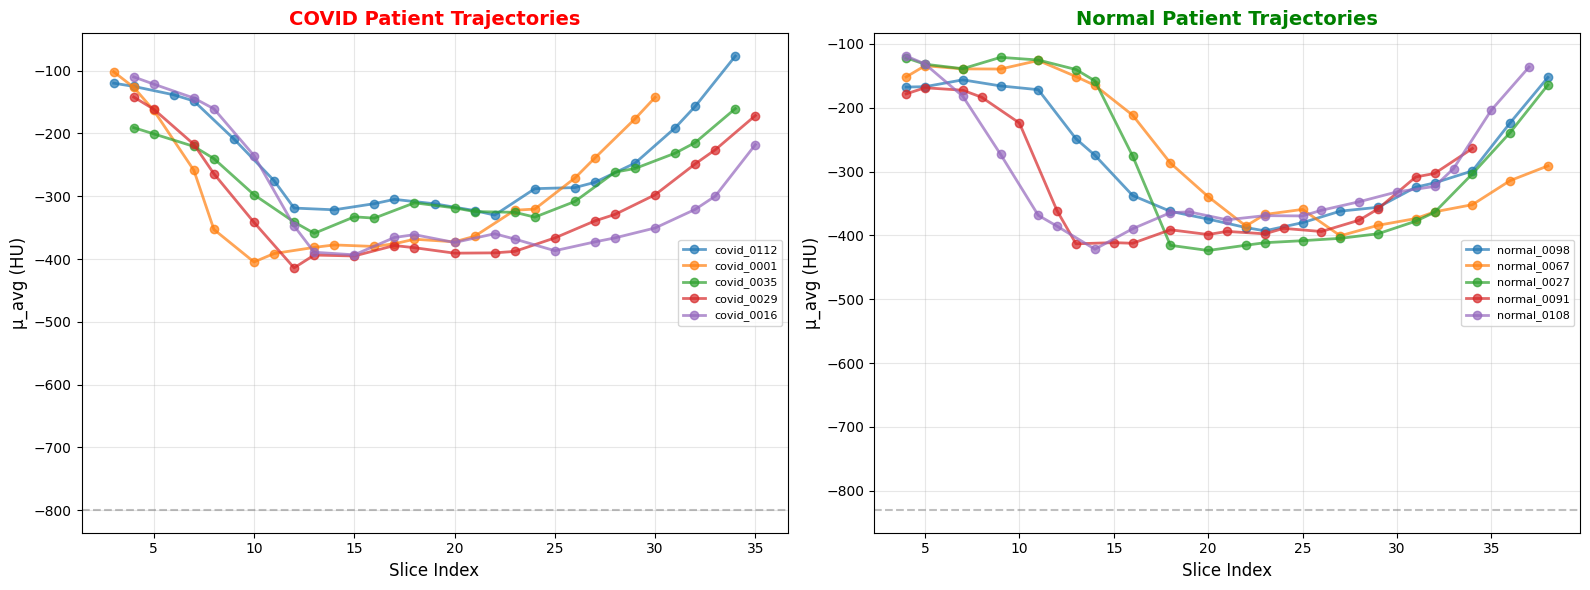

Saved: /kaggle/working/sanity/covid_vs_normal_trajectories.png

COVID:
  Within-patient std: 88.77 HU
  Between-patient std: 36.86 HU
  Within/Between ratio: 2.41

Normal:
  Within-patient std: 101.91 HU
  Between-patient std: 42.97 HU
  Within/Between ratio: 2.37


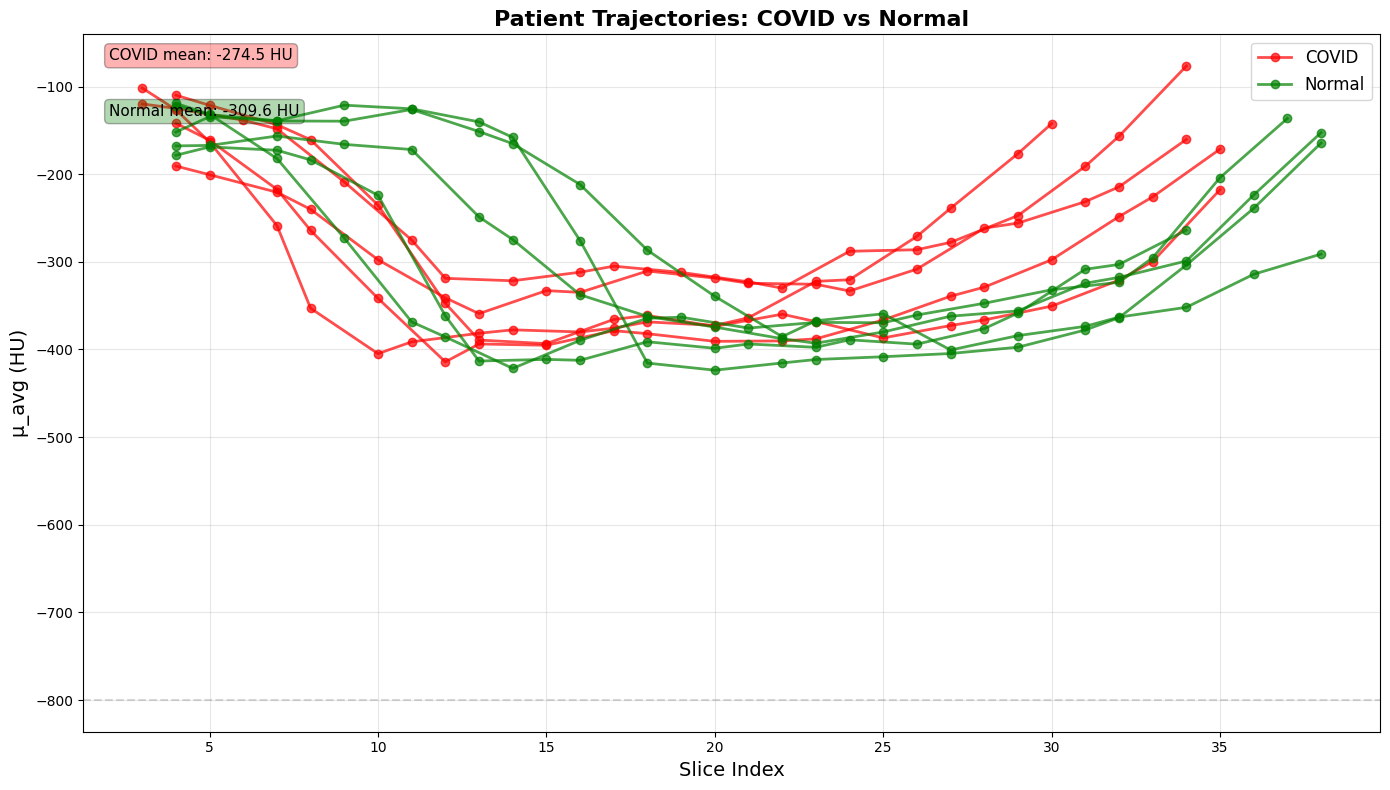

Saved: /kaggle/working/sanity/combined_trajectories.png


In [12]:
train_df, val_df, test_df = load_frozen_dataset(
    '/kaggle/input/output-data/frozen_datasets/covid_ct_lungmask_INTERVAL_v2'
)
plot_patient_trajectories_covid_vs_normal(train_df, n_samples=5)
plot_combined_trajectories(train_df, n_covid=5, n_normal=5)